In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
ds=pd.read_csv("C:/Users/HP/Desktop/Preterm.csv")
ds

,Age,Weight,Height,BMI,BMI_Category,pretermhistory
0,37,55,164,20.20,2,0
1,23,42,150,18.67,2,0
2,28,48,161,18.52,2,0
3,39,75,159,29.67,3,0
4,30,82,170,28.40,2,1
...,...,...,...,...,...,...
59,15,48,150,17.63,1,0
60,31,65,158,27.06,3,0
61,27,45,149,20.00,2,0
62,35,85,170,29.40,3,1


In [3]:
df=[ds.columns]
df

[Index([' Age ', 'Weight', 'Height', 'BMI', 'BMI_Category', 'pretermhistory'], dtype='object')]

In [4]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0    Age            64 non-null     int64  
 1   Weight          64 non-null     int64  
 2   Height          64 non-null     int64  
 3   BMI             64 non-null     float64
 4   BMI_Category    64 non-null     int64  
 5   pretermhistory  64 non-null     int64  
dtypes: float64(1), int64(5)
memory usage: 3.1 KB


In [5]:
ds.duplicated()


0     False
1     False
2     False
3     False
4     False
      ...  
59    False
60    False
61    False
62    False
63    False
Length: 64, dtype: bool

In [6]:
ds.corr()

,Age,Weight,Height,BMI,BMI_Category,pretermhistory
Age,1.000000,0.482319,0.443970,0.240972,0.299698,0.207790
Weight,0.482319,1.000000,0.824845,0.553989,0.628421,0.737244
Height,0.443970,0.824845,1.000000,0.337616,0.317760,0.677200
BMI,0.240972,0.553989,0.337616,1.000000,0.625918,0.365620
BMI_Category,0.299698,0.628421,0.317760,0.625918,1.000000,0.353820
pretermhistory,0.207790,0.737244,0.677200,0.365620,0.353820,1.000000


In [7]:
ds

,Age,Weight,Height,BMI,BMI_Category,pretermhistory
0,37,55,164,20.20,2,0
1,23,42,150,18.67,2,0
2,28,48,161,18.52,2,0
3,39,75,159,29.67,3,0
4,30,82,170,28.40,2,1
...,...,...,...,...,...,...
59,15,48,150,17.63,1,0
60,31,65,158,27.06,3,0
61,27,45,149,20.00,2,0
62,35,85,170,29.40,3,1


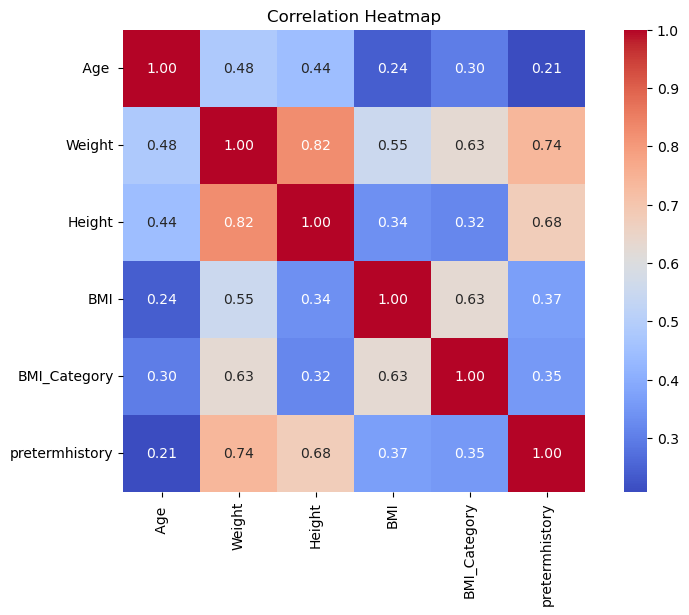

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(ds)

# Convert categorical variable to numeric for correlation
df['BMI_Category'] = df['BMI_Category'].astype('category').cat.codes

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 6))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar=True)

# Title
plt.title('Correlation Heatmap')

# Show the plot
plt.show()


In [17]:
from sklearn.model_selection import train_test_split

In [19]:
x=ds[[' Age ','Height','Weight','BMI_Category']]
y=ds[['pretermhistory']]

from sklearn.preprocessing import StandardScaler


sc=StandardScaler()
x=pd.DataFrame(sc.fit_transform(x),columns=[' Age ','Height','Weight','BMI_Category'])

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)
cls=LogisticRegression()


cls.fit(X_train,y_train)
result=cls.predict(X_test)
accuracy=accuracy_score(y_test,result)
accuracy

1.0

In [12]:
Age= int(input("Enter Age:"))
Height=int(input("Enter Height:"))
Weight=int(input("Enter Weight:"))
BMI_Category=float(input("Enter BMI_Category:"))
columns=[' Age ','Height','Weight','BMI_Category']
myinput1=pd.DataFrame(columns=columns,data=[[Age,Height,Weight,BMI_Category]])
result=cls.predict(myinput1)
result

if result==1:
    print("BMI_Category:","Normal")
elif result==2:
    print("BMI_Category:","underweight")
else:
    print("BMI_Category:","Obesity")

if result==1:
    print("Mode of Delivery:","Preterm birth")
else:
       print("Mode of Delivery:","Normal")

Enter Age: 27
Enter Height: 145
Enter Weight: 67
Enter BMI_Category: 3


BMI_Category: Normal
Mode of Delivery: Preterm birth


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Assuming df is your DataFrame
X = ds[[' Age ','Height','Weight','BMI_Category']]# Features
y = ds['pretermhistory']  # Target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Random Forest Model
rf = RandomForestClassifier(n_estimators=100, random_state=50)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9230769230769231
              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       1.00      0.75      0.86         4

    accuracy                           0.92        13
   macro avg       0.95      0.88      0.90        13
weighted avg       0.93      0.92      0.92        13



Accuracy: 0.77


TypeError: can only concatenate str (not "numpy.int64") to str

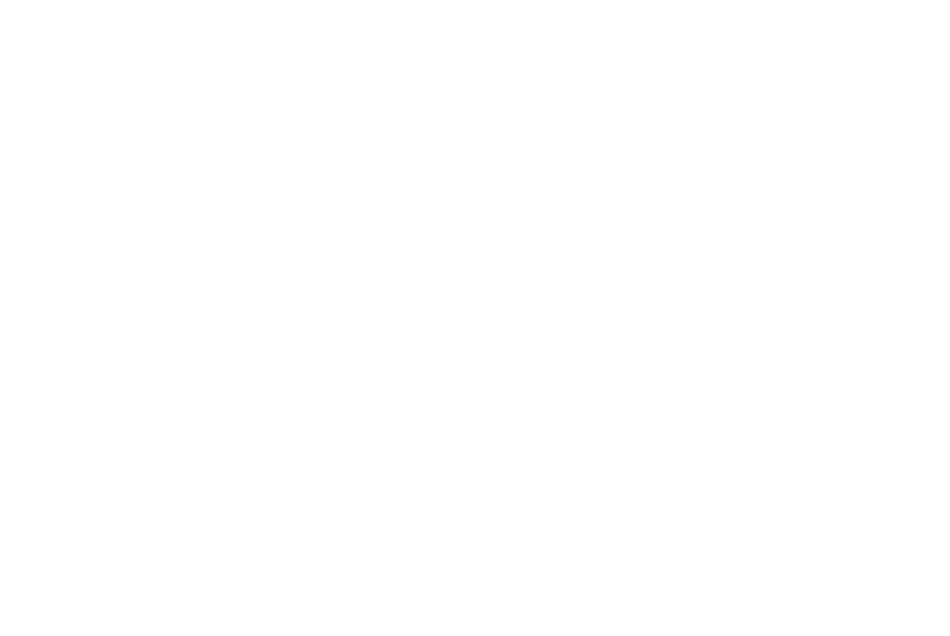

In [14]:
# Importing necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Assuming 'ds' is your DataFrame
# Features and target variables
X = ds[[' Age ','Height','Weight','BMI_Category']]
y = ds['pretermhistory']

# If your target variable 'Mode' is categorical, it needs to be encoded to numeric
encoder = LabelEncoder()
y = encoder.fit_transform(y.values.ravel())  # Flattening the target variable array

# Splitting the dataset into training and testing sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on the training set
dt_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = dt_model.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Optional: Visualize the Decision Tree (if needed)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plot_tree(dt_model, feature_names=x.columns, class_names=encoder.classes_, filled=True)
plt.show()


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
ohe = OneHotEncoder()
ohe.fit(X[[" Age ", "Weight", "Height","BMI_Category"]])

In [ ]:
ct = make_column_transformer((OneHotEncoder(categories = ohe.categories_), 
                              [" Age ", "Weight", "Height","BMI_Category"]), remainder = 'passthrough', force_int_remainder_cols=False)

In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [ ]:
from sklearn.pipeline import make_pipeline
pipe = make_pipeline(ct, reg)

In [ ]:
#training and testing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
scores = []
for i in range(0, 101):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.05, random_state = i)
    pipe.fit(X_train, y_train)
    result = pipe.predict(X_test)
    score = r2_score(y_test, result)
    scores.append(score)

In [ ]:
bestindex = np.argmax(scores)

In [ ]:
scores[bestindex]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.05, random_state = bestindex)
pipe.fit(X_train, y_train)

In [ ]:
Age= int(input("Enter Age:"))
Height=int(input("Enter Height:"))
Weight=int(input("Enter Weight:"))
BMI_Category=float(input("Enter BMI_Category:"))
columns=[' Age ','Height','Weight','BMI_Category']
myinput1=pd.DataFrame(columns=columns,data=[[Age,Height,Weight,BMI_Category]])
result= pipe.predict(myinput1)
result

if result==1:
    print("BMI_Category:","Normal")
elif result==2:
    print("BMI_Category:","underweight")
else:
    print("BMI_Category:","Obesity")

if result==0:
    print("Mode of Delivery:","Normal")
else:
       print("Mode of Delivery:","preterm birth")

In [ ]:
import pickle as pkl
pkl.dump(pipe, open("Preterm.pkl", "wb"))

In [ ]:
class CustomClass:
    pass

obj=CustomClass()
pkl.dump(obj,open("Preterm.pkl", "wb"))